# 중고차 가격 예측 — 회귀 모델 분석

본 노트북은 **전처리 파이프라인 노트북의 실행 결과를 그대로 이어받아** 회귀 모델링을 수행한다.

**전처리 노트북 최종 산출물 (이 노트북이 사용하는 변수)**

| 변수 | 내용 | 전처리 단계 |
|------|------|------------|
| `X_train`, `X_test` | OHE + Target Encoding + StandardScaler 완료 | Step 8~11 |
| `y_train_log`, `y_test_log` | log1p 변환된 가격 | Step 9 |
| `df_final` | 인코딩 완료 전체 데이터 (split 전) | Step 8 |

**비교 구조**

| 버전 | 설명 |
|------|------|
| Baseline | `estimate_msrp` 컬럼 제외 |
| Enhanced | `estimate_msrp` 컬럼 포함 |


## Step 1. 라이브러리 임포트

In [ ]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110,
                     'axes.spines.top': False,
                     'axes.spines.right': False})

print("라이브러리 로드 완료")


라이브러리 로드 완료


## Step 2. 전처리 결과 확인

전처리 노트북 실행 후 메모리에 남아있는 변수를 그대로 사용한다.
별도 CSV 로드나 재인코딩 없이 바로 이어서 진행한다.


In [ ]:
# Verify preprocessed variables
print("=" * 55)
print("  Preprocessing outputs")
print("=" * 55)
print(f"  X_train  : {X_train.shape}")
print(f"  X_test   : {X_test.shape}")
print(f"  y_train_log : {y_train_log.shape}  (log transform done)")
print(f"  y_test_log  : {y_test_log.shape}   (log transform done)")
print()
print(f"  Feature list ({X_train.shape[1]}):")
for col in X_train.columns:
    print(f"    - {col}")
print()
print(f"  estimate_msrp included: {'estimate_msrp' in X_train.columns}")


  Preprocessing outputs
  X_train  : (4000, 50)
  X_test   : (1000, 50)
  y_train_log : (4000,)  (log transform done)
  y_test_log  : (1000,)   (log transform done)

  Feature list (50):
    - condition
    - odometer
    - vehicle_age
    - estimate_msrp
    - cylinders_12
    - cylinders_3
    - cylinders_4
    - cylinders_5
    - cylinders_6
    - cylinders_8
    - cylinders_other
    - manufacturer_chevrolet
    - manufacturer_dodge
    - manufacturer_ford
    - manufacturer_gmc
    - manufacturer_honda
    - manufacturer_hyundai
    - manufacturer_jeep
    - manufacturer_kia
    - manufacturer_lexus
    - manufacturer_mercedes-benz
    - manufacturer_nissan
    - manufacturer_other
    - manufacturer_ram
    - manufacturer_subaru
    - manufacturer_toyota
    - manufacturer_volkswagen
    - fuel_electric
    - fuel_gas
    - fuel_hybrid
    - fuel_other
    - transmission_manual
    - transmission_other
    - type_coupe
    - type_other
    - type_pickup
    - type_sedan
    - typ

## Step 3. Baseline / Enhanced 데이터 분기

전처리 완료된 `X_train` / `X_test`에서 `estimate_msrp` 컬럼 유무로 두 버전을 분기한다.

- **Baseline** : 기존 차량 정보만 사용 (`estimate_msrp` 제외)
- **Enhanced** : LLM 추정 출고가 포함 (`estimate_msrp` 포함)

> R²는 피처 수가 많아질수록 자동으로 증가하는 특성이 있다.  
> Baseline(피처 n개) vs Enhanced(피처 n+1개) 비교 시 단순 R² 상승이  
> MSRP의 실질 기여인지 피처 수 증가 효과인지 구분하기 위해 **Adjusted R²를 병행** 사용한다.


In [ ]:
# Baseline: exclude estimate_msrp
X_train_base = X_train.drop(columns=['estimate_msrp'], errors='ignore').copy()
X_test_base  = X_test.drop(columns=['estimate_msrp'],  errors='ignore').copy()

# Enhanced: use preprocessed result as-is (estimate_msrp included)
X_train_enh  = X_train.copy()
X_test_enh   = X_test.copy()

print(f"Baseline  features: {X_train_base.shape[1]}")
print(f"Enhanced  features: {X_train_enh.shape[1]}")
print(f"  Diff: 1 feature (estimate_msrp)")
print()
print(f"Shared y — Train: {y_train_log.shape}  Test: {y_test_log.shape}")


Baseline  features: 49
Enhanced  features: 50
  Diff: 1 feature (estimate_msrp)

Shared y — Train: (4000,)  Test: (1000,)


## Step 4. 다중공선성(VIF) 분석

회귀 모델 투입 전, 수치형 피처 간 다중공선성을 VIF(Variance Inflation Factor)로 확인한다.

- VIF < 5 : 다중공선성 없음 ✅
- VIF 5~10 : 주의 필요 ⚠️
- VIF > 10 : 다중공선성 있음 → 제거 또는 결합 검토 ❌

> OHE로 생성된 이진(0/1) 더미 변수들은 VIF가 인위적으로 높게 측정될 수 있으므로  
> 수치형 원본 피처 위주로 확인한다.


Numerical features for VIF (5): ['condition', 'odometer', 'vehicle_age', 'estimate_msrp', 'model_encoded']

      Feature      VIF
model_encoded 1.823748
     odometer 1.789305
  vehicle_age 1.671358
estimate_msrp 1.484582
    condition 1.103515


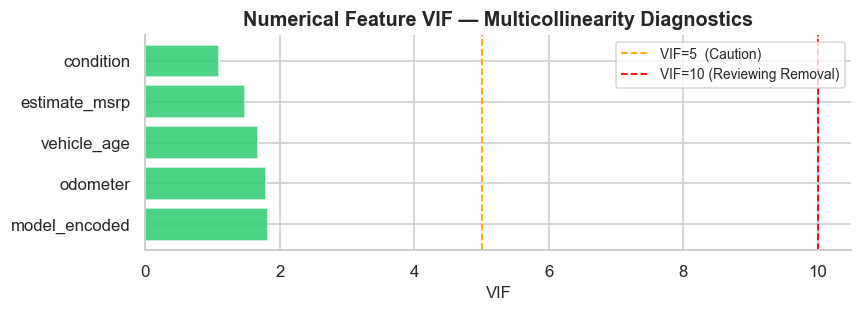

In [ ]:
# Select numerical features only (exclude OHE dummy columns)
num_cols_vif = X_train_enh.select_dtypes(include=[np.number]).columns.tolist()
# Exclude binary dummies (columns with only 0/1 values)
num_cols_vif = [c for c in num_cols_vif
                if X_train_enh[c].nunique() > 2]

print(f"Numerical features for VIF ({len(num_cols_vif)}): {num_cols_vif}")

if len(num_cols_vif) >= 2:
    X_vif = X_train_enh[num_cols_vif].dropna()
    X_vif_c = add_constant(X_vif)

    vif_df = pd.DataFrame({
        'Feature': num_cols_vif,
        'VIF': [variance_inflation_factor(X_vif_c.values, i+1)
                for i in range(len(num_cols_vif))]
    }).sort_values('VIF', ascending=False)

    print()
    print(vif_df.to_string(index=False))

    fig, ax = plt.subplots(figsize=(8, max(3, len(num_cols_vif) * 0.6)))
    colors = ['#e74c3c' if v > 10 else '#f39c12' if v > 5 else '#2ecc71'
              for v in vif_df['VIF']]
    ax.barh(vif_df['Feature'], vif_df['VIF'], color=colors, alpha=0.85)
    ax.axvline(5,  color='orange', linestyle='--', linewidth=1.2, label='VIF=5  (Caution)')
    ax.axvline(10, color='red',    linestyle='--', linewidth=1.2, label='VIF=10 (Reviewing Removal)')
    ax.set_xlabel('VIF', fontsize=11)
    ax.set_title('Numerical Feature VIF — Multicollinearity Diagnostics', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("Less than 2 numerical features — VIF skipped")


## Step 5. 회귀 모델 선택 근거

### 1. Linear Regression
**통계적 가정 (이 단계에서 사전 확인 필요)**

| 가정 | 내용 | 확인 방법 |
|------|------|----------|
| 선형성 | y와 X 간 선형 관계 | 잔차 vs 예측값 산점도 (Step 8) |
| 정규성 | 잔차가 정규분포 | Q-Q Plot (Step 8) |
| 등분산성 | 잔차 분산이 일정 | 잔차 분포 (Step 8) |
| 독립성 | 관측치 간 잔차 독립 | 크로스섹션 데이터 → 비교적 만족 가정 |
| 다중공선성 | 피처 간 상관 없음 | VIF (Step 4) |

**선택 이유**: 회귀계수를 통해 각 피처의 가격 영향력(방향 + 크기)을 직접 해석 가능  
**한계**: 비선형 관계 포착 불가, 가정 위반 시 편향 추정

### 2. Decision Tree Regressor
**통계적 가정**: 없음 (비모수적)  
**선택 이유**: 피처 간 비선형 상호작용 포착, 차량 가격의 조건별 비선형 변화 반영  
**한계**: `max_depth` 미지정 시 과적합 심각

### 3. Random Forest Regressor
**통계적 가정**: 없음 (앙상블)  
**선택 이유**: 다수 트리 평균으로 과적합 억제, 피처 중요도 제공, 이상치에 강인  
**한계**: 계산 비용 높음, 회귀계수 수준 직접 해석 불가


## Step 6. 모델 정의

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree":     DecisionTreeRegressor(random_state=42),
    "Random Forest":     RandomForestRegressor(n_estimators=100,
                                               random_state=42,
                                               n_jobs=-1),
}

def adjusted_r2(r2, n, p):
    """Adjusted R² — corrects for R² inflation from additional features"""
    if n - p - 1 <= 0:
        return np.nan
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

def eval_model(y_true_log, y_pred_log, n_features):
    """Compute dollar-unit metrics after inverse log transform"""
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    n  = len(y_true)
    r2 = r2_score(y_true_log, y_pred_log)   # log-scale R²
    return {
        "MAE":     mean_absolute_error(y_true, y_pred),
        "RMSE":    np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2":      r2,
        "Adj_R2":  adjusted_r2(r2, n, n_features),
    }

print("모델 및 평가 기능 준비 완료")


모델 및 평가 기능 준비 완료


## Step 7. 모델 학습 및 성능 평가

각 모델을 Baseline / Enhanced 두 버전으로 학습하고  
MAE, RMSE, R², **Adjusted R²** 로 평가한다.

> `y_train_log` / `y_test_log` : 전처리 Step 9에서 log1p 변환 완료  
> 예측값은 `np.expm1()` 역변환 후 달러 단위 오차로 보고


In [ ]:
results       = []
fitted_models = {}

for name, model in models.items():
    print("=" * 60)
    print(f"  {name}")
    print("=" * 60)

    for version, X_tr, X_te, label in [
        ("Baseline", X_train_base, X_test_base, "Baseline (estimate_msrp excluded)"),
        ("Enhanced", X_train_enh,  X_test_enh,  "Enhanced (estimate_msrp included)"),
    ]:
        m = clone(model)
        m.fit(X_tr, y_train_log)
        pred_log = m.predict(X_te)

        metrics = eval_model(y_test_log, pred_log, X_te.shape[1])

        print(f"  [{label}]")
        print(f"    MAE: ${metrics['MAE']:>9,.0f}  |  "
              f"RMSE: ${metrics['RMSE']:>9,.0f}  |  "
              f"R²: {metrics['R2']:.4f}  |  "
              f"Adj.R²: {metrics['Adj_R2']:.4f}")

        results.append({
            "Model":      name,
            "Version":    version,
            "Label":      label,
            "MAE":        metrics["MAE"],
            "RMSE":       metrics["RMSE"],
            "R2":         metrics["R2"],
            "Adj_R2":     metrics["Adj_R2"],
            "n_features": X_te.shape[1],
            "pred_log":   pred_log,
        })
        fitted_models[f"{name}_{version}"] = m

print("\n교육 및 평가 완료")


  Linear Regression
  [Baseline (estimate_msrp excluded)]
    MAE: $    3,876  |  RMSE: $    6,101  |  R²: 0.8430  |  Adj.R²: 0.8349
  [Enhanced (estimate_msrp included)]
    MAE: $    3,326  |  RMSE: $    5,099  |  R²: 0.8654  |  Adj.R²: 0.8583
  Decision Tree
  [Baseline (estimate_msrp excluded)]
    MAE: $    3,450  |  RMSE: $    6,084  |  R²: 0.7047  |  Adj.R²: 0.6894
  [Enhanced (estimate_msrp included)]
    MAE: $    3,292  |  RMSE: $    5,625  |  R²: 0.7384  |  Adj.R²: 0.7246
  Random Forest
  [Baseline (estimate_msrp excluded)]
    MAE: $    2,957  |  RMSE: $    5,383  |  R²: 0.8047  |  Adj.R²: 0.7947
  [Enhanced (estimate_msrp included)]
    MAE: $    2,753  |  RMSE: $    4,688  |  R²: 0.8285  |  Adj.R²: 0.8195

교육 및 평가 완료


## Step 7-1. 회귀계수 분석 (Linear Regression)

**어떤 피처가 가격에 얼마나 영향을 주는가?**

전처리에서 StandardScaler가 수치형 피처에 적용되어 있으므로,  
회귀계수의 절댓값으로 피처 간 영향력을 **공정하게 비교**할 수 있다.

- 계수 > 0 : 해당 피처 증가 → 가격 **상승**
- 계수 < 0 : 해당 피처 증가 → 가격 **하락**
- 절댓값이 클수록 → 가격에 미치는 영향 큼


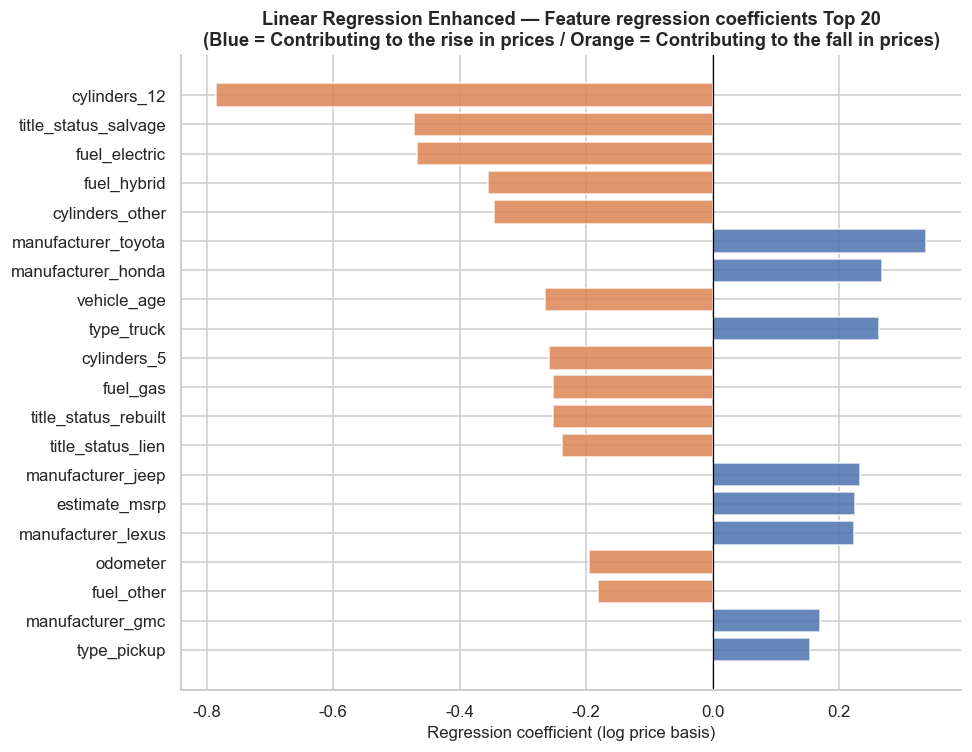

[Top 10 — Contributing to price increase]
             Feature  Coefficient
        cylinders_12    -0.784412
title_status_salvage    -0.471534
       fuel_electric    -0.467914
         fuel_hybrid    -0.355355
     cylinders_other    -0.345939
 manufacturer_toyota     0.337264
  manufacturer_honda     0.267213
         vehicle_age    -0.264770
          type_truck     0.263006
         cylinders_5    -0.257982

[Bottom 10 — Contributing to price decrease]
           Feature  Coefficient
         drive_rwd     0.031037
  manufacturer_kia     0.027967
paint_color_silver    -0.024904
   paint_color_red     0.024544
 paint_color_white     0.023889
 paint_color_other     0.022417
  paint_color_blue    -0.016143
transmission_other     0.011774
       cylinders_8     0.011077
  paint_color_grey    -0.001217


In [ ]:
lr_enh = fitted_models["Linear Regression_Enhanced"]

coef_df = pd.DataFrame({
    'Feature':     X_train_enh.columns,
    'Coefficient': lr_enh.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

# Top 20 features
top_n   = 20
top_c   = coef_df.head(top_n)
colors  = ['#4C72B0' if v >= 0 else '#DD8452' for v in top_c['Coefficient']]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top_c['Feature'][::-1], top_c['Coefficient'][::-1],
        color=colors[::-1], alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Regression coefficient (log price basis)', fontsize=11)
ax.set_title(f'Linear Regression Enhanced — Feature regression coefficients Top {top_n}\n'
             f'(Blue = Contributing to the rise in prices / Orange = Contributing to the fall in prices)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("[Top 10 — Contributing to price increase]")
print(coef_df.head(10)[['Feature','Coefficient']].to_string(index=False))
print("\n[Bottom 10 — Contributing to price decrease]")
print(coef_df.tail(10)[['Feature','Coefficient']].to_string(index=False))


## Step 8. 모델 성능 비교

**해석 주의사항**
- R²는 피처 수 증가만으로도 상승 → Enhanced(피처 +1개)가 유리할 수 있음
- **Adjusted R² 기준으로 MSRP 실질 기여도 판단**
- ΔAdj R² > 0 이면 estimate_msrp가 실질적으로 성능에 기여한 것


In [ ]:
results_df = pd.DataFrame(results).drop(columns=['pred_log'])

main_df = results_df.copy()

# Pivot table
pivot = main_df.pivot_table(
    index='Model', columns='Version',
    values=['MAE','RMSE','R2','Adj_R2']
).round(4)
pivot.columns = ['_'.join(c) for c in pivot.columns]
pivot = pivot.reset_index()

pivot['ΔR2']     = (pivot['R2_Enhanced']    - pivot['R2_Baseline']).round(4)
pivot['ΔAdj_R2'] = (pivot['Adj_R2_Enhanced']- pivot['Adj_R2_Baseline']).round(4)
pivot['ΔRMSE']   = (pivot['RMSE_Enhanced']  - pivot['RMSE_Baseline']).round(2)

display(pivot.style
    .background_gradient(cmap='YlGnBu',
                         subset=['R2_Baseline','R2_Enhanced',
                                 'Adj_R2_Baseline','Adj_R2_Enhanced'])
    .background_gradient(cmap='RdYlGn', subset=['ΔR2','ΔAdj_R2'])
    .set_caption("Model Performance Comparison — Baseline vs Enhanced (incl. Adj R²)")
    .format({c: '{:.4f}' for c in pivot.columns
             if any(k in c for k in ['R2','Δ'])})
    .format({c: '${:,.0f}' for c in pivot.columns
             if any(k in c for k in ['MAE','RMSE']) and 'Δ' not in c})
    .set_properties(**{'text-align':'center'})
)


,Model,Adj_R2_Baseline,Adj_R2_Enhanced,MAE_Baseline,MAE_Enhanced,R2_Baseline,R2_Enhanced,RMSE_Baseline,RMSE_Enhanced,ΔR2,ΔAdj_R2,ΔRMSE
0,Decision Tree,0.689400,0.724600,"$3,450","$3,292",0.704700,0.738400,"$6,084","$5,625",0.033700,0.035200,-459.340000
1,Linear Regression,0.834900,0.858300,"$3,876","$3,326",0.843000,0.865400,"$6,101","$5,099",0.022400,0.023400,-1002.200000
2,Random Forest,0.794700,0.819500,"$2,957","$2,753",0.804700,0.828500,"$5,383","$4,688",0.023800,0.024800,-694.470000


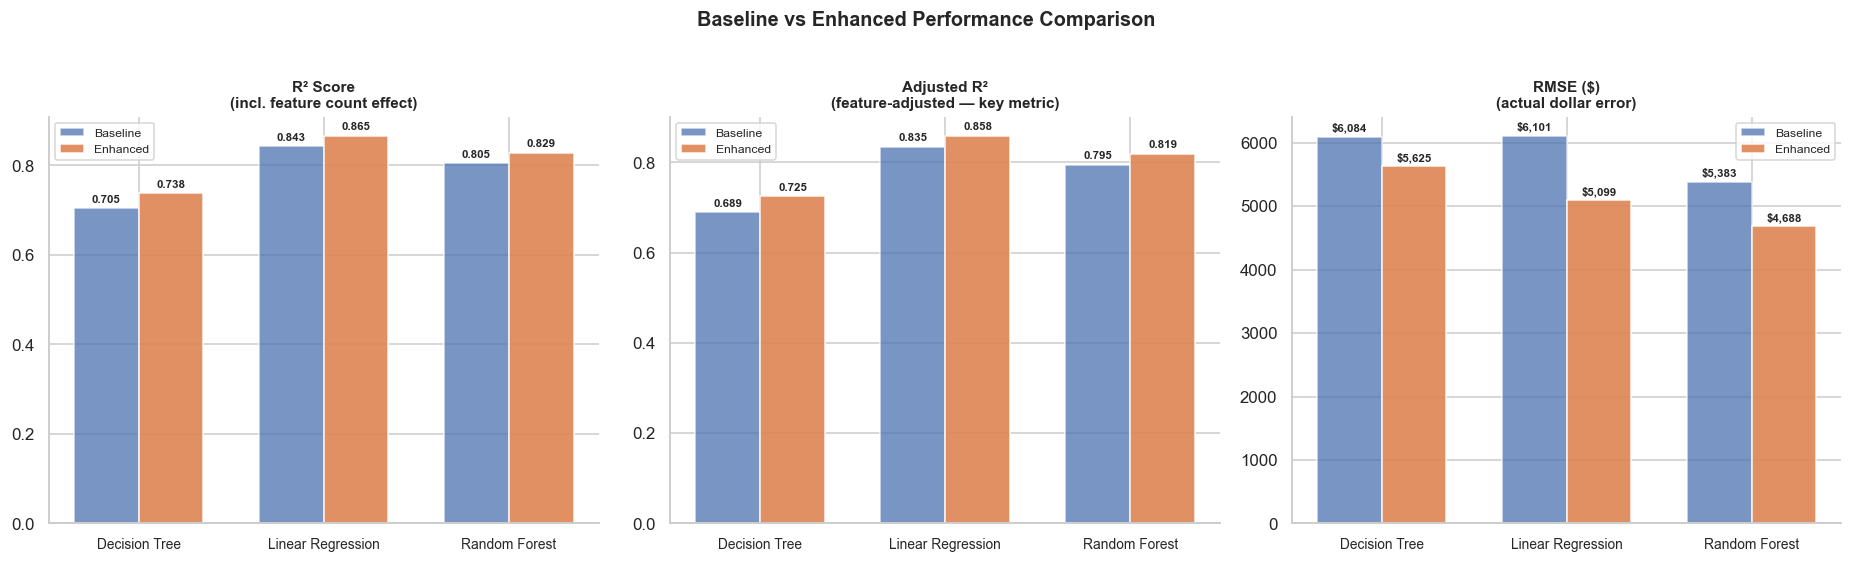

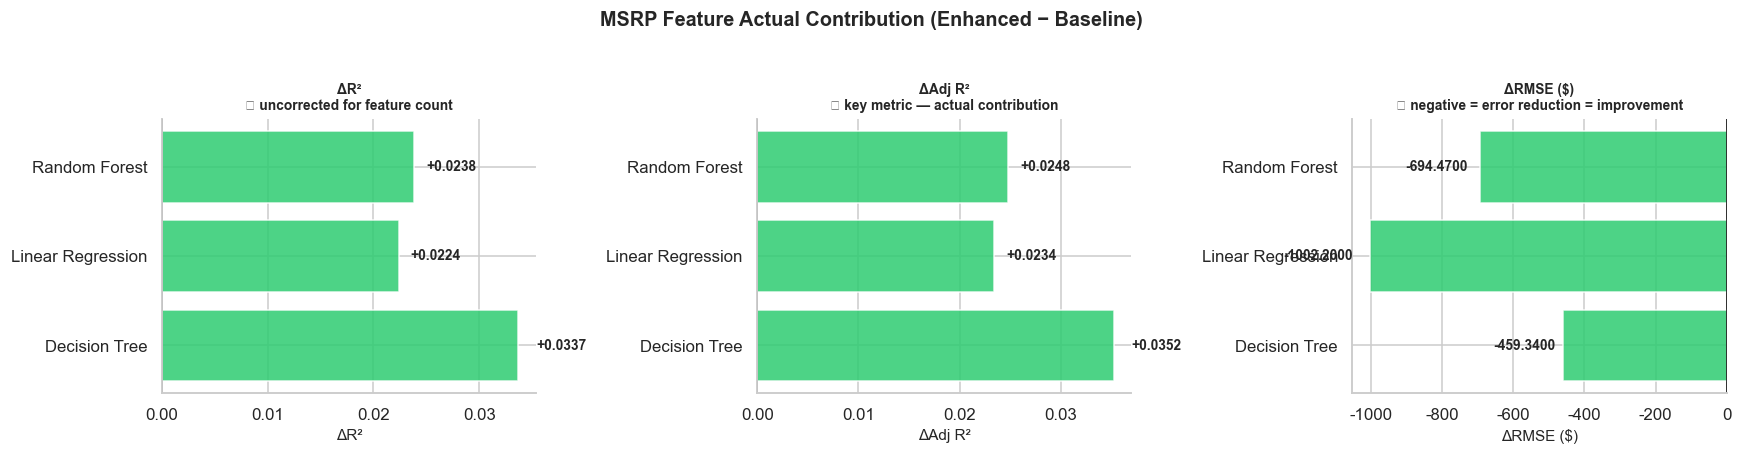

In [ ]:
# ── (A) 3-metric Grouped Bar ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (metric, title, fmt) in zip(axes, [
    ('R2',   'R² Score\n(incl. feature count effect)',         '{:.3f}'),
    ('Adj_R2','Adjusted R²\n(feature-adjusted — key metric)', '{:.3f}'),
    ('RMSE', 'RMSE ($)\n(actual dollar error)',             '${:,.0f}'),
]):
    pv = main_df.pivot(index='Model', columns='Version', values=metric)
    x  = np.arange(len(pv)); w = 0.35
    b1 = ax.bar(x-w/2, pv['Baseline'], w, label='Baseline',
                color='#4C72B0', alpha=0.75)
    b2 = ax.bar(x+w/2, pv['Enhanced'], w, label='Enhanced',
                color='#DD8452', alpha=0.9)
    ax.set_xticks(x); ax.set_xticklabels(pv.index, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    for bar in list(b1)+list(b2):
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h*1.01,
                fmt.format(h), ha='center', va='bottom',
                fontsize=7.5, fontweight='bold')

plt.suptitle("Baseline vs Enhanced Performance Comparison",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── (B) MSRP Feature Delta Horizontal Bar ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (col, xlabel, note, invert) in zip(axes, [
    ('ΔR2',     'ΔR²',     '※ uncorrected for feature count',      False),
    ('ΔAdj_R2', 'ΔAdj R²', '※ key metric — actual contribution',  False),
    ('ΔRMSE',   'ΔRMSE ($)','※ negative = error reduction = improvement',      True),
]):
    vals = pivot.set_index('Model')[col]
    good = lambda v: (v >= 0) if not invert else (v <= 0)
    colors = ['#2ecc71' if good(v) else '#e74c3c' for v in vals]
    ax.barh(vals.index, vals, color=colors, alpha=0.85)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_title(f"{xlabel}\n{note}", fontsize=9, fontweight='bold')
    for i, v in enumerate(vals):
        off = abs(v)*0.05 if v != 0 else 1e-4
        ax.text(v+(off if v>=0 else -off), i,
                f'{v:+.4f}', va='center',
                ha='left' if v>=0 else 'right',
                fontsize=9, fontweight='bold')

plt.suptitle("MSRP Feature Actual Contribution (Enhanced − Baseline)",
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


## Step 9. 실제 가격 vs 예측 가격 비교 및 잔차 분석

최고 성능 모델의 예측값을 `np.expm1()` 역변환하여 실제 달러 단위로 시각화한다.

잔차 분석으로 Linear Regression의 핵심 가정(정규성, 등분산성)을 사후 검증한다.


Best model: Linear Regression (Enhanced)
  Adj R² = 0.8583 | RMSE = $5,099


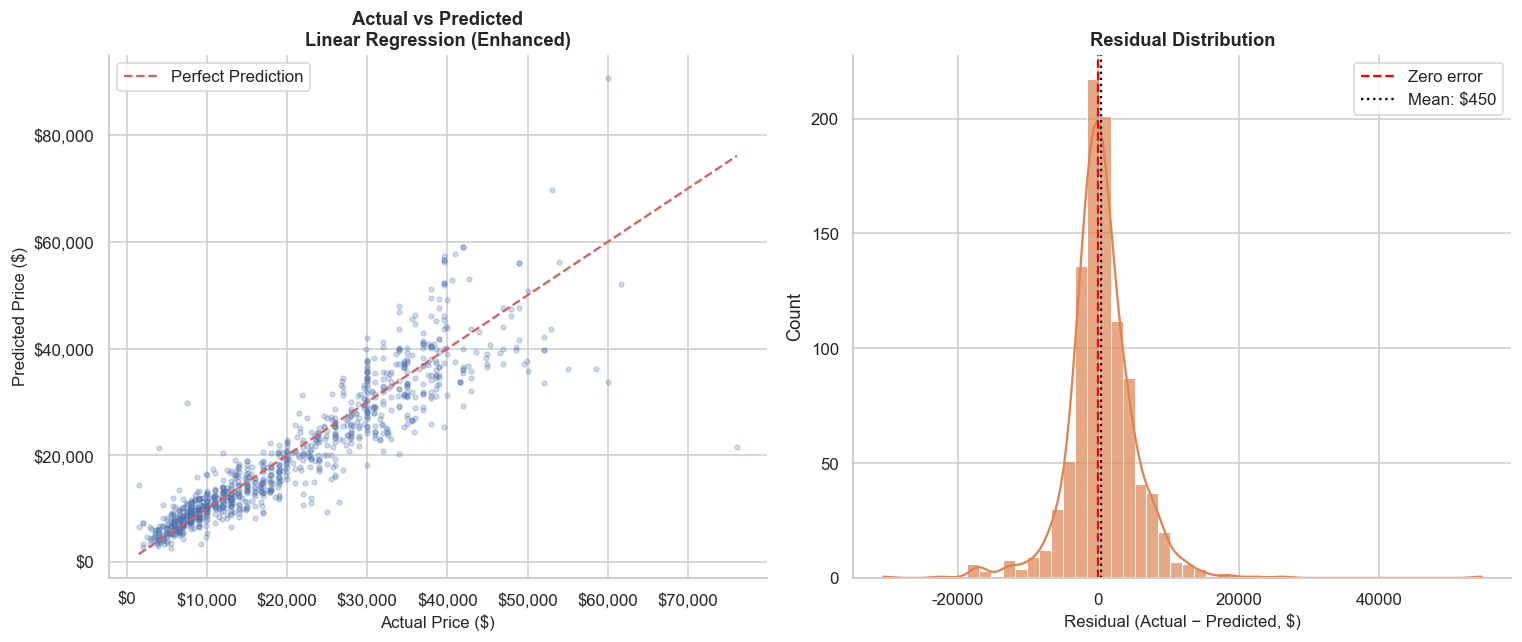

In [ ]:
# Best model (auto-selected by Adj R²)
best_row     = main_df.sort_values('Adj_R2', ascending=False).iloc[0]
best_name    = best_row['Model']
best_version = best_row['Version']
best_m       = fitted_models[f"{best_name}_{best_version}"]
X_te_best    = X_test_enh if best_version == "Enhanced" else X_test_base
pred_log_best = best_m.predict(X_te_best)

print(f"Best model: {best_name} ({best_version})")
print(f"  Adj R² = {best_row['Adj_R2']:.4f} | RMSE = ${best_row['RMSE']:,.0f}")

y_actual  = np.expm1(y_test_log)
y_pred    = np.expm1(pred_log_best)
residuals = y_actual - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot
ax = axes[0]
ax.scatter(y_actual, y_pred, alpha=0.25, s=10, color='#4C72B0')
lim = [y_actual.min(), y_actual.max()]
ax.plot(lim, lim, 'r--', linewidth=1.5, label='Perfect Prediction')
ax.set_xlabel("Actual Price ($)", fontsize=11)
ax.set_ylabel("Predicted Price ($)", fontsize=11)
ax.set_title(f"Actual vs Predicted\n{best_name} ({best_version})",
             fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.legend()

# Residual distribution
ax = axes[1]
sns.histplot(residuals, bins=50, kde=True, color='#DD8452', ax=ax, alpha=0.7)
ax.axvline(0,               color='red',   linestyle='--', linewidth=1.5,
           label='Zero error')
ax.axvline(residuals.mean(),color='black', linestyle=':',  linewidth=1.5,
           label=f'Mean: ${residuals.mean():,.0f}')
ax.set_xlabel("Residual (Actual − Predicted, $)", fontsize=11)
ax.set_title("Residual Distribution", fontsize=12, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()


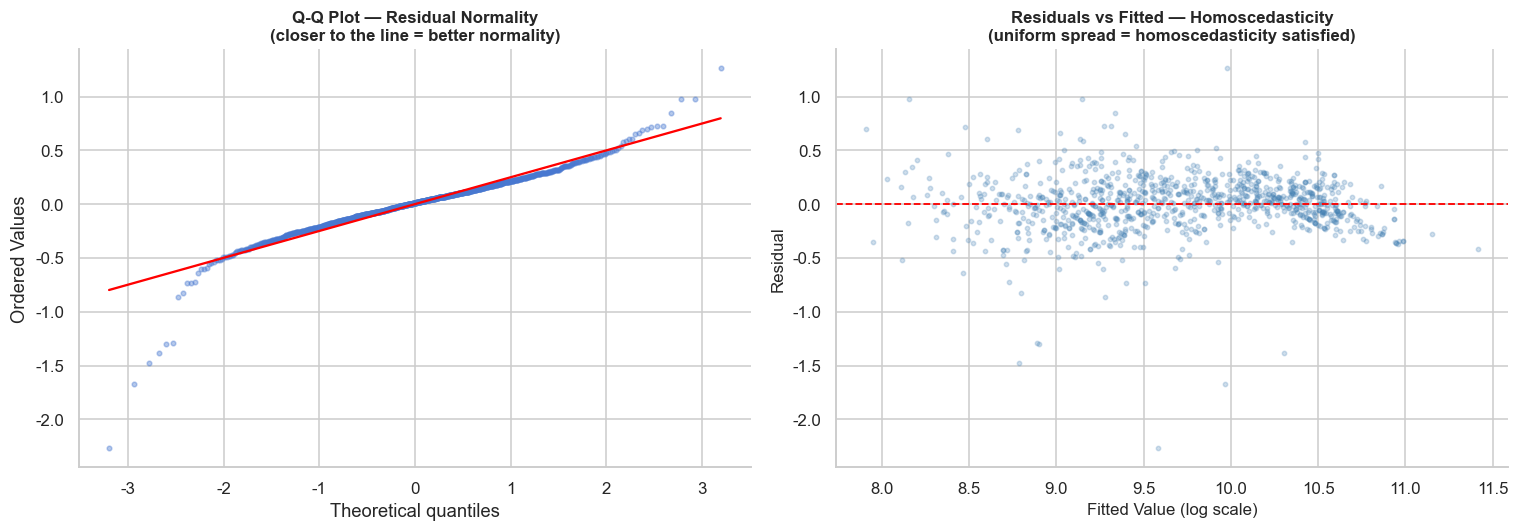

In [ ]:
# Linear Regression assumption check (residual normality · homoscedasticity)
lr_pred_log = fitted_models["Linear Regression_Enhanced"].predict(X_test_enh)
lr_resid    = y_test_log - lr_pred_log   # log-scale residuals

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Q-Q Plot — normality
ax = axes[0]
stats.probplot(lr_resid, dist="norm", plot=ax)
ax.set_title("Q-Q Plot — Residual Normality\n(closer to the line = better normality)",
             fontsize=11, fontweight='bold')
ax.get_lines()[0].set(markersize=3, alpha=0.4)
ax.get_lines()[1].set(color='red', linewidth=1.5)

# Residuals vs Fitted — homoscedasticity
ax = axes[1]
ax.scatter(lr_pred_log, lr_resid, alpha=0.25, s=8, color='steelblue')
ax.axhline(0, color='red', linestyle='--', linewidth=1.2)
ax.set_xlabel("Fitted Value (log scale)", fontsize=11)
ax.set_ylabel("Residual", fontsize=11)
ax.set_title("Residuals vs Fitted — Homoscedasticity\n(uniform spread = homoscedasticity satisfied)",
             fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


## Step 10. 이상점(Outlier) 및 영향점(Influential Point) 분석

- **이상점**: 표준화 잔차 절댓값 > 3 인 관측치
- **영향점**: Cook's Distance > 4/n 인 관측치

> 모든 이상점을 제거하는 것이 옳은 것은 아니다.  
> 해당 관측치가 실무적으로 타당한 데이터인지 맥락을 파악한 후 유지/제거 여부를 판단해야 한다.


Standardized residuals > 3 (outliers): 45 (1.1%)

Cook's Distance > 4/n influential points: 22

[Top 5 observations by Cook's Distance]
      odometer  vehicle_age  estimate_msrp  price_log
4214 -1.188011    -0.631341       2.279611  11.155550
1714 -0.726734    -0.867401      -0.055251   9.510519
2021 -0.138037    -0.631341      -0.306895   9.798127
2663 -0.914608    -1.339520      -0.683967   9.928229
1477  0.686122     0.548957       5.248677   9.093919


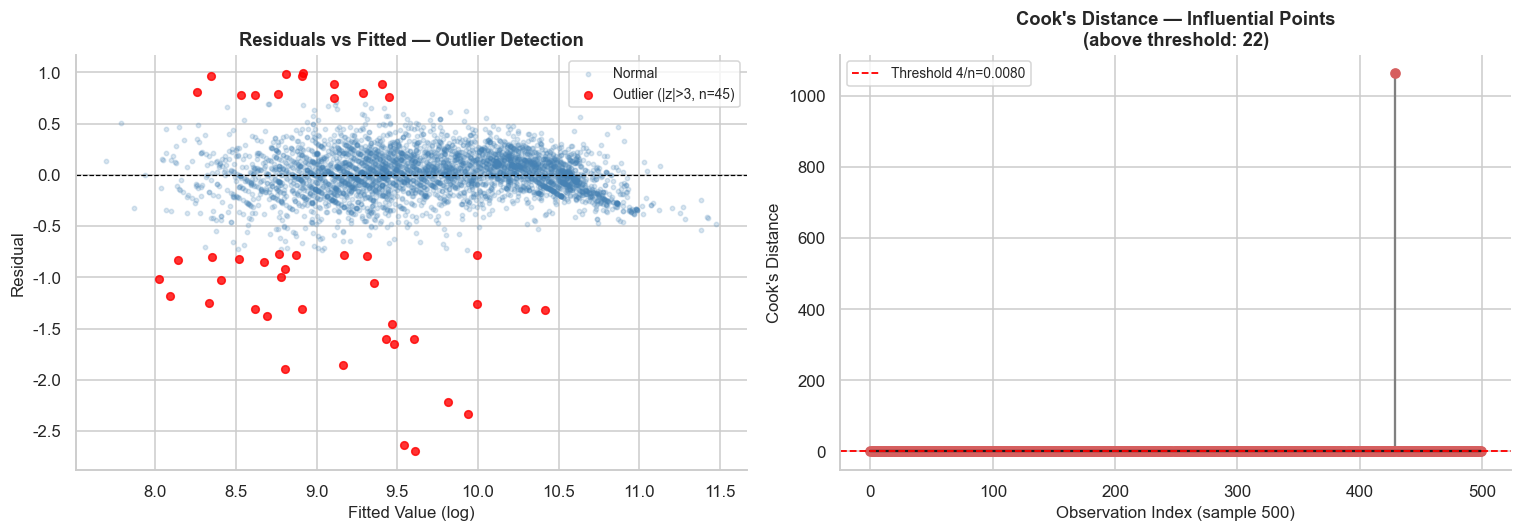

In [ ]:
lr_m      = fitted_models["Linear Regression_Enhanced"]
pred_tr   = lr_m.predict(X_train_enh)
resid_tr  = y_train_log - pred_tr
resid_std = (resid_tr - resid_tr.mean()) / resid_tr.std()

outlier_mask = resid_std.abs() > 3
print(f"Standardized residuals > 3 (outliers): {outlier_mask.sum()} "
      f"({outlier_mask.sum()/len(resid_std)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Fitted (outliers highlighted)
ax = axes[0]
ax.scatter(pred_tr[~outlier_mask], resid_tr[~outlier_mask],
           alpha=0.2, s=8,  color='steelblue', label='Normal')
ax.scatter(pred_tr[outlier_mask],  resid_tr[outlier_mask],
           alpha=0.8, s=25, color='red',
           label=f'Outlier (|z|>3, n={outlier_mask.sum()})')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel("Fitted Value (log)", fontsize=11)
ax.set_ylabel("Residual", fontsize=11)
ax.set_title("Residuals vs Fitted — Outlier Detection",
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

# Cook's Distance (sample 500)
ax = axes[1]
try:
    n_sample = min(500, len(X_train_enh))
    X_ols = add_constant(X_train_enh.values[:n_sample])
    y_ols = y_train_log.values[:n_sample]
    ols_res    = OLS(y_ols, X_ols).fit()
    cooks_d    = ols_res.get_influence().cooks_distance[0]
    threshold  = 4 / n_sample
    influential = cooks_d > threshold

    ax.stem(np.arange(len(cooks_d)), cooks_d,
            markerfmt='ro', linefmt='grey', basefmt='k-')
    ax.axhline(threshold, color='red', linestyle='--', linewidth=1.2,
               label=f"Threshold 4/n={threshold:.4f}")
    ax.set_xlabel(f"Observation Index (sample {n_sample})", fontsize=11)
    ax.set_ylabel("Cook's Distance", fontsize=11)
    ax.set_title(f"Cook's Distance — Influential Points\n"
                 f"(above threshold: {influential.sum()})",
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

    print(f"\nCook's Distance > 4/n influential points: {influential.sum()}")
    top5 = np.argsort(cooks_d)[-5:][::-1]
    sample_ref = pd.concat([X_train_enh, y_train_log.rename('price_log')],
                            axis=1).iloc[:n_sample]
    num_show = [c for c in ['odometer','vehicle_age','estimate_msrp','price_log']
                if c in sample_ref.columns]
    print("\n[Top 5 observations by Cook's Distance]")
    print(sample_ref.iloc[top5][num_show])

except Exception as e:
    ax.text(0.5, 0.5, f"Calculation error\n{e}", transform=ax.transAxes, ha='center')
    print(f"Cook's Distance calculation error: {e}")

plt.tight_layout()
plt.show()


## Step 11. price_class 생성 — Classification 연계

Random Forest Enhanced 모델의 예측값 기반으로 `price_class`를 생성하고 저장한다.

**분류 기준 (gap_ratio = (실제가격 − 예측가격) / 예측가격)**

| 클래스 | 조건 | 의미 |
|--------|------|------|
| 0 | gap_ratio < -0.10 | Underpriced (시세보다 저렴) |
| 1 | -0.10 ≤ gap_ratio ≤ 0.10 | Fairly Priced (시세 적정) |
| 2 | gap_ratio > 0.10 | Overpriced (시세보다 비쌈) |

> ※ 전체 데이터(`df_final`) 기반 예측이므로 Train 포함. Classification 노트북에서 별도 split 적용 필요.


▶ gap_ratio descriptive statistics:
count    5000.0000
mean        1.1381
std         1.2508
min        -0.8860
25%         0.0531
50%         0.8449
75%         2.1440
max         8.4533
Name: gap_ratio, dtype: float64

▶ Classification threshold  |  Underpriced: gap < 0.2812  |  Overpriced: gap > 1.7964

▶ price_class distribution:
  0 Underpriced  :   1650 (33.0%)
  1 Fairly Priced:   1700 (34.0%)
  2 Overpriced   :   1650 (33.0%)


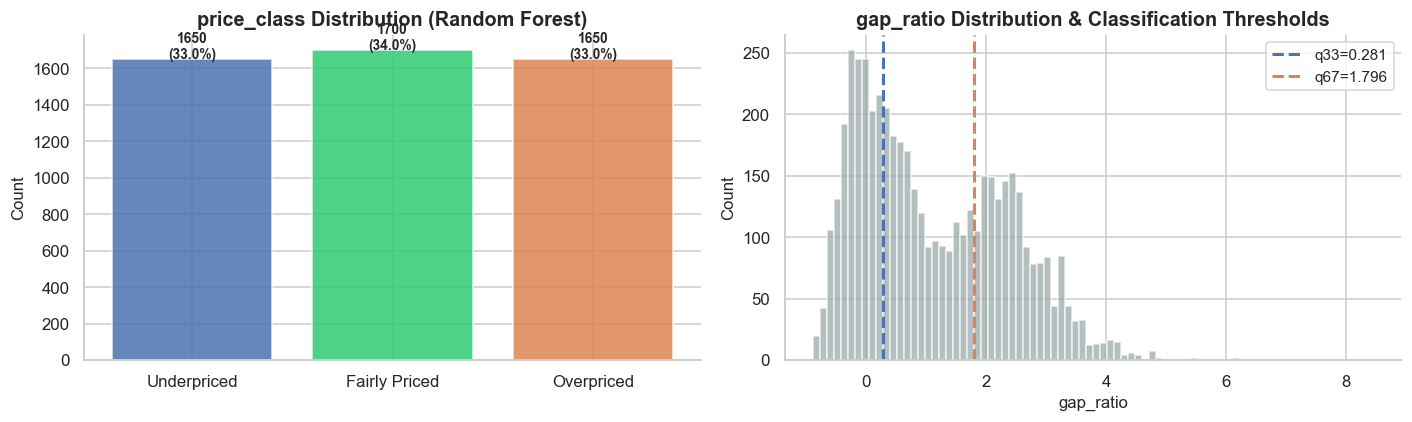


 vehicles_with_price_class.csv saved


In [ ]:
# ── Model selection: Random Forest Enhanced ──────────────────────────────────────
rf_enh = fitted_models["Random Forest_Enhanced"]

# ── Prepare features from df_final ────────────────────────────────────────────────
X_full = df_final.drop(columns=['price'], errors='ignore')

missing = set(X_train_enh.columns) - set(X_full.columns)
if missing:
    print(f"Warning: missing features {missing} — filled with 0")
    for col in missing:
        X_full[col] = 0
X_full = X_full[X_train_enh.columns]

# ── Predict (log scale → inverse transform) ─────────────────────────────────────────────
pred_log_full = rf_enh.predict(X_full)
df_final_out  = df_final.copy()
df_final_out["predicted_price"] = np.expm1(pred_log_full)
df_final_out["gap_ratio"] = (
    (df_final_out["price"] - df_final_out["predicted_price"])
    / df_final_out["predicted_price"]
)

# ── Check gap_ratio distribution first ──────────────────────────────────────────────
print("▶ gap_ratio descriptive statistics:")
print(df_final_out["gap_ratio"].describe().round(4))

# ── Quantile-based classification (ensures balanced 33:34:33 split) ───────────────────────────
q33 = df_final_out["gap_ratio"].quantile(0.33)
q67 = df_final_out["gap_ratio"].quantile(0.67)
print(f"\n▶ Classification threshold  |  Underpriced: gap < {q33:.4f}  |  Overpriced: gap > {q67:.4f}")

def classify_price(gap):
    if gap < q33: return 0   # Underpriced
    elif gap > q67: return 2  # Overpriced
    else:           return 1  # Fairly Priced

df_final_out["price_class"] = df_final_out["gap_ratio"].apply(classify_price)

# ── Print distribution ─────────────────────────────────────────────────────────────
dist = df_final_out["price_class"].value_counts().sort_index()
total = len(df_final_out)
print("\n▶ price_class distribution:")
print(f"  0 Underpriced  : {dist.get(0,0):>6} ({dist.get(0,0)/total*100:.1f}%)")
print(f"  1 Fairly Priced: {dist.get(1,0):>6} ({dist.get(1,0)/total*100:.1f}%)")
print(f"  2 Overpriced   : {dist.get(2,0):>6} ({dist.get(2,0)/total*100:.1f}%)")

# ── Visualization ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: price_class bar chart
colors = ['#4C72B0', '#2ecc71', '#DD8452']
labels = ['Underpriced', 'Fairly Priced', 'Overpriced']
bars = axes[0].bar(labels, [dist.get(i, 0) for i in range(3)],
                   color=colors, alpha=0.85, edgecolor='white')
axes[0].set_ylabel("Count", fontsize=11)
axes[0].set_title("price_class Distribution (Random Forest)", fontsize=13, fontweight='bold')
for i, v in enumerate([dist.get(j, 0) for j in range(3)]):
    axes[0].text(i, v + 5, f"{v}\n({v/total*100:.1f}%)",
                 ha='center', fontsize=9, fontweight='bold')

# Right: gap_ratio histogram + classification threshold lines
axes[1].hist(df_final_out["gap_ratio"], bins=80, color='#95a5a6', alpha=0.7, edgecolor='white')
axes[1].axvline(q33, color='#4C72B0', linestyle='--', linewidth=2, label=f'q33={q33:.3f}')
axes[1].axvline(q67, color='#DD8452', linestyle='--', linewidth=2, label=f'q67={q67:.3f}')
axes[1].set_xlabel("gap_ratio", fontsize=11)
axes[1].set_ylabel("Count", fontsize=11)
axes[1].set_title("gap_ratio Distribution & Classification Thresholds", fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

# ── Save CSV ──────────────────────────────────────────────────────────────
df_final_out.to_csv("vehicles_with_price_class.csv", index=False)
print("\n vehicles_with_price_class.csv saved")

## Step 12. 최종 결론

In [ ]:
print("=" * 65)
print("  Final Summary — Regression Model Performance")
print("=" * 65)

best_row = main_df.sort_values('Adj_R2', ascending=False).iloc[0]
base_row = main_df[(main_df['Model']    == best_row['Model']) &
                   (main_df['Version']  == 'Baseline')].iloc[0]

print(f"\n  Best Model     : {best_row['Model']} (Enhanced)")
print(f"  R²             : {best_row['R2']:.4f}")
print(f"  Adjusted R²    : {best_row['Adj_R2']:.4f}")
print(f"  RMSE           : ${best_row['RMSE']:,.0f}")
print(f"  MAE            : ${best_row['MAE']:,.0f}")
print()
print(f"  MSRP Feature Contribution (vs Baseline)")
print(f"  ΔR²            : {best_row['R2']    - base_row['R2']:+.4f}")
print(f"  ΔAdj R²        : {best_row['Adj_R2']- base_row['Adj_R2']:+.4f}  ← actual contribution metric")
print(f"  ΔRMSE          : ${best_row['RMSE']  - base_row['RMSE']:+,.0f}")
print()
print("  [Interpretation]")
adj_delta = best_row['Adj_R2'] - base_row['Adj_R2']
if adj_delta > 0:
    print(f"  ΔAdj R² = {adj_delta:+.4f} > 0")
    print("  → estimate_msrp feature contributes to prediction improvement")
    print("    beyond the effect of simply adding more features")
else:
    print(f"  ΔAdj R² = {adj_delta:+.4f} ≤ 0")
    print("  → estimate_msrp feature contribution does not outweigh the cost")
    print("    (R² increase is likely due to added feature count)")
print("=" * 65)


  Final Summary — Regression Model Performance

  Best Model     : Linear Regression (Enhanced)
  R²             : 0.8654
  Adjusted R²    : 0.8583
  RMSE           : $5,099
  MAE            : $3,326

  MSRP Feature Contribution (vs Baseline)
  ΔR²            : +0.0224
  ΔAdj R²        : +0.0234  ← actual contribution metric
  ΔRMSE          : $-1,002

  [Interpretation]
  ΔAdj R² = +0.0234 > 0
  → estimate_msrp feature contributes to prediction improvement
    beyond the effect of simply adding more features
